In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
with open("/content/drive/MyDrive/Haystack/manual.json", "r", encoding="utf-8") as file:
  manual=json.load(file)

# save the contexts, titles and pages for later use
contexts = [document["context"] for document in manual]
titles = [document["title"] for document in manual]
pages = [document["page"] for document in manual]

with open("/content/drive/MyDrive/Haystack/LDS_current_scores.json", "r", encoding="utf-8") as file:
  LDS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_scores.json", "r", encoding="utf-8") as file:
  LDS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_queries.json", "r", encoding="utf-8") as file:
  LDS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

LDS_current_queries = [conversation["Queries"] for conversation in manual_QAs["LDS"]]

with open("/content/drive/MyDrive/Haystack/LDS_queries_difference.json", "r", encoding="utf-8") as file:
  LDS_info_hiding_rate=json.load(file)

Mounted at /content/drive


In [ ]:
with open("/content/drive/MyDrive/Haystack/ESS_current_scores.json", "r", encoding="utf-8") as file:
  ESS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/ESS_rewritten_scores.json", "r", encoding="utf-8") as file:
  ESS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/ESS_rewritten_queries.json", "r", encoding="utf-8") as file:
  ESS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

ESS_current_queries = [conversation["Queries"] for conversation in manual_QAs["ESS"]]

with open("/content/drive/MyDrive/Haystack/ESS_queries_difference.json", "r", encoding="utf-8") as file:
  ESS_info_hiding_rate=json.load(file)

with open("/content/drive/MyDrive/Haystack/RNS_current_scores.json", "r", encoding="utf-8") as file:
  RNS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/RNS_rewritten_scores.json", "r", encoding="utf-8") as file:
  RNS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/RNS_rewritten_queries.json", "r", encoding="utf-8") as file:
  RNS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

RNS_current_queries = [conversation["Queries"] for conversation in manual_QAs["RNS"]]

with open("/content/drive/MyDrive/Haystack/RNS_queries_difference.json", "r", encoding="utf-8") as file:
  RNS_info_hiding_rate=json.load(file)

In [ ]:
all_info_hiding_rate = [rate for conversation in LDS_info_hiding_rate for rate in conversation]
all_info_hiding_rate.extend([rate for conversation in ESS_info_hiding_rate for rate in conversation])
all_info_hiding_rate.extend([rate for conversation in RNS_info_hiding_rate for rate in conversation])

all_info_hiding_rate = [max(0, min(1, x)) for x in all_info_hiding_rate]

all_current_scores = [sum(score)/len(score) for conversation in LDS_current_scores for score in conversation]
all_current_scores.extend([sum(score)/len(score) for conversation in ESS_current_scores for score in conversation])
all_current_scores.extend([sum(score)/len(score) for conversation in RNS_current_scores for score in conversation])

print(len(all_info_hiding_rate), len(all_current_scores))

2090 2090


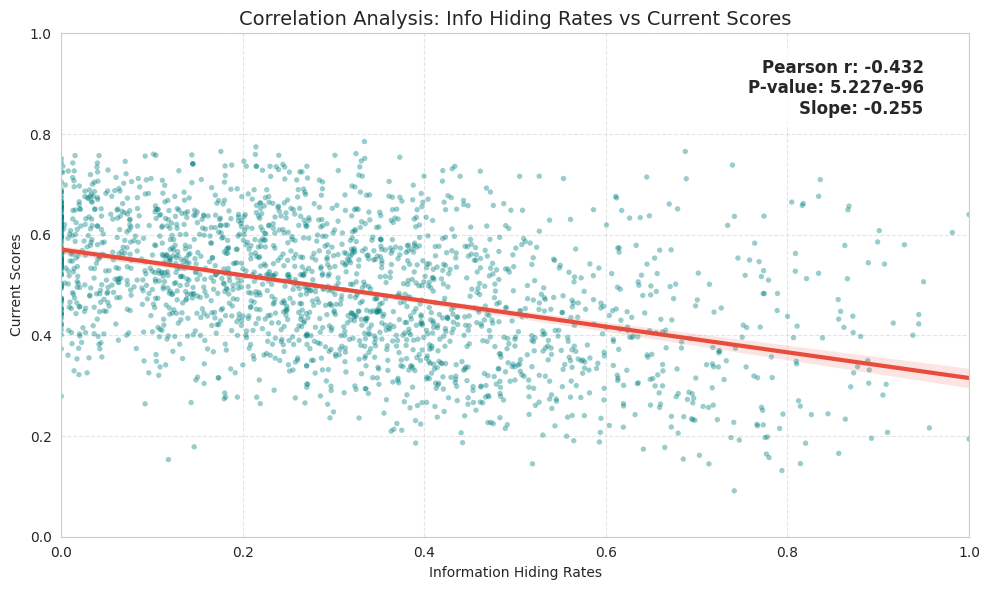

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats  # 用于计算统计指标

# 1. 计算统计指标 (相关系数 r 和 p-value)
slope, intercept, r_value, p_value, std_err = stats.linregress(all_info_hiding_rate, all_current_scores)

plt.figure(figsize=(10, 6))

# 2. 绘制带拟合线的散点图
sns.regplot(x=all_info_hiding_rate, y=all_current_scores,
            scatter_kws={'s': 15, 'alpha': 0.4, 'edgecolors': 'none'},
            line_kws={'color': '#e74c3c', 'lw': 3}, # 使用更醒目的红色
            color='teal')

# 3. 在图上显示具体指标
# 我们把文字放在右上角空白处 (x=0.65, y=0.85 附近)
stats_text = (f'Pearson r: {r_value:.3f}\n'
              f'P-value: {p_value:.3e}\n'
              f'Slope: {slope:.3f}')

# 使用 bbox 给文字加一个半透明底色，防止被点遮挡
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes, # 使用相对坐标 (0-1)
         verticalalignment='top',
         horizontalalignment='right',
         fontsize=12,
         fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

# 4. 图表修饰
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Correlation Analysis: Info Hiding Rates vs Current Scores', fontsize=14)
plt.xlabel('Information Hiding Rates')
plt.ylabel('Current Scores')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

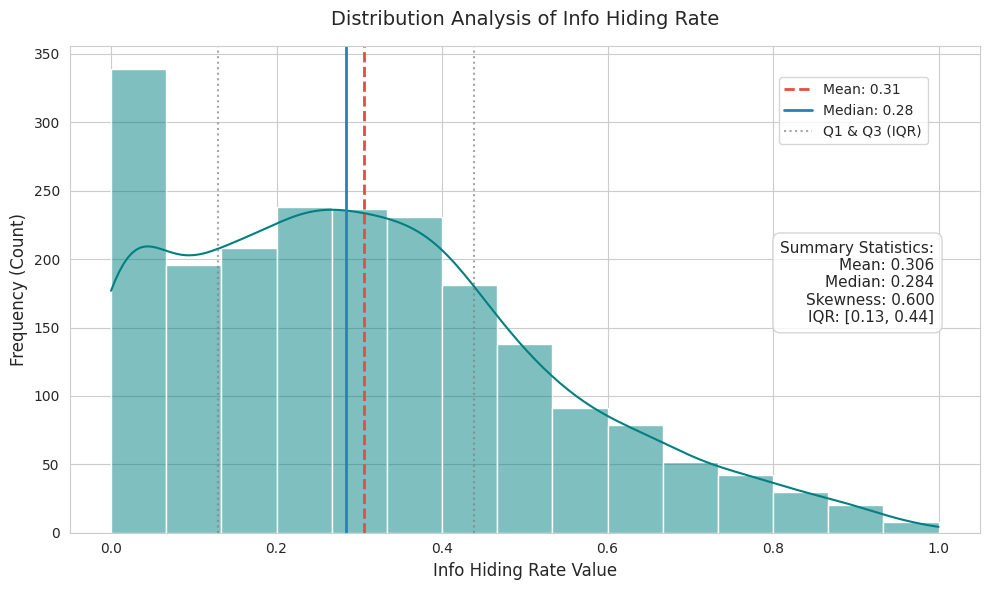

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew # 导入计算偏度的函数

# 1. 计算更丰富的统计量
mean_val = np.mean(all_info_hiding_rate)
median_val = np.median(all_info_hiding_rate)
q1 = np.percentile(all_info_hiding_rate, 25)
q3 = np.percentile(all_info_hiding_rate, 75)
data_skew = skew(all_info_hiding_rate) # 计算偏度

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 2. 绘制主图 (调整了 alpha 让网格线更清晰)
sns.histplot(all_info_hiding_rate, kde=True, bins=15, color="teal", alpha=0.5, edgecolor='white')

# 3. 绘制统计线
# 均值 (红虚线)
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
# 中位数 (蓝实线) - 对于偏态分布，中位数比均值更能代表“典型值”
plt.axvline(median_val, color='#2980b9', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
# 四分位数 (灰色细虚线) - 展示中间 50% 数据的范围
plt.axvline(q1, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Q1 & Q3 (IQR)')
plt.axvline(q3, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

# 4. 在图右上角添加一个综合统计信息框
# 这种方式在学术论文中非常直观，不需要读者去对坐标轴
stats_box = (f'Summary Statistics:\n'
             f'Mean: {mean_val:.3f}\n'
             f'Median: {median_val:.3f}\n'
             f'Skewness: {data_skew:.3f}\n'
             f'IQR: [{q1:.2f}, {q3:.2f}]')

plt.text(0.95, 0.6, stats_box, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc', boxstyle='round,pad=0.5'))

# 5. 修饰图表
plt.title('Distribution Analysis of Info Hiding Rate', fontsize=14, pad=15)
plt.xlabel('Info Hiding Rate Value', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xlim(-0.05, 1.05) # 留出一点边缘美感
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # 调整图例位置防止遮挡

plt.tight_layout()
plt.show()

In [ ]:
def linear_weighted_decay(lst):
  m = len(lst)
  if m == 0:
    return 0
  denominator = m*(m+1)
  weighted_sum = sum(2 * (i + 1) * d for i, d in enumerate(lst))
  return weighted_sum/denominator

weighted_info_hiding_rate = [linear_weighted_decay(conversation) for conversation in LDS_info_hiding_rate]
weighted_info_hiding_rate.extend([linear_weighted_decay(conversation) for conversation in ESS_info_hiding_rate])
weighted_info_hiding_rate.extend([linear_weighted_decay(conversation) for conversation in RNS_info_hiding_rate])

weighted_info_hiding_rate = [max(0, min(1, x)) for x in weighted_info_hiding_rate]

weighted_current_scores = [linear_weighted_decay([sum(score)/len(score) for score in conversation]) for conversation in LDS_current_scores]
weighted_current_scores.extend([linear_weighted_decay([sum(score)/len(score) for score in conversation]) for conversation in ESS_current_scores])
weighted_current_scores.extend([linear_weighted_decay([sum(score)/len(score) for score in conversation]) for conversation in RNS_current_scores])

print(len(weighted_info_hiding_rate), len(weighted_current_scores))

120 120


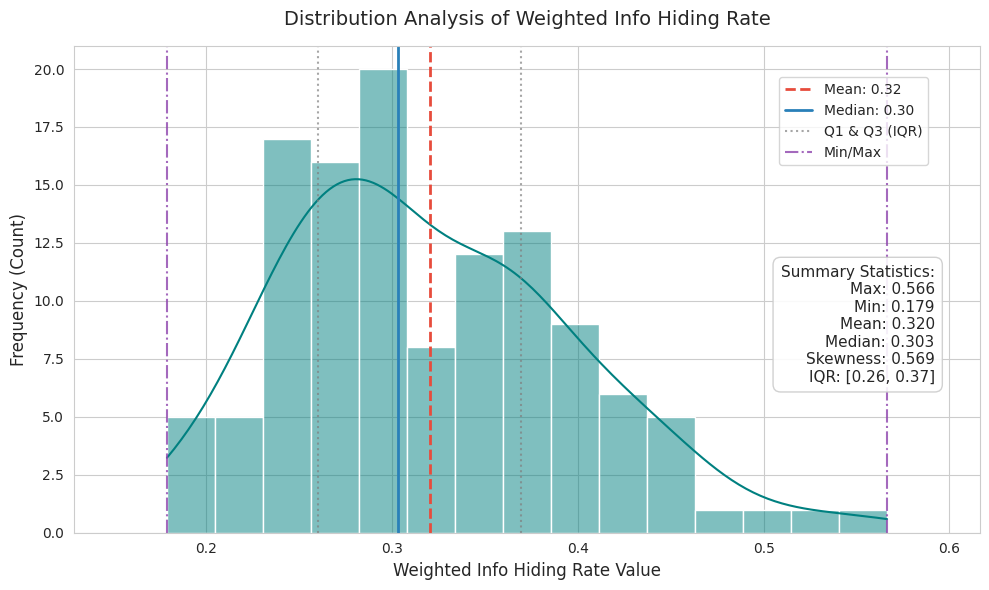

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew

# 1. 计算更丰富的统计量 (新增 max, min)
mean_val = np.mean(weighted_info_hiding_rate)
median_val = np.median(weighted_info_hiding_rate)
q1 = np.percentile(weighted_info_hiding_rate, 25)
q3 = np.percentile(weighted_info_hiding_rate, 75)
max_val = np.max(weighted_info_hiding_rate) # 新增
min_val = np.min(weighted_info_hiding_rate) # 新增
data_skew = skew(weighted_info_hiding_rate)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 2. 绘制主图
sns.histplot(weighted_info_hiding_rate, kde=True, bins=15, color="teal", alpha=0.5, edgecolor='white')

# 3. 绘制统计线
# 均值 (红虚线)
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
# 中位数 (蓝实线)
plt.axvline(median_val, color='#2980b9', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
# 四分位数 (灰色细虚线)
plt.axvline(q1, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Q1 & Q3 (IQR)')
plt.axvline(q3, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

# --- 新增：最大值与最小值 (紫色点划线) ---
plt.axvline(max_val, color='#8e44ad', linestyle='-.', linewidth=1.5, alpha=0.8, label=f'Min/Max')
plt.axvline(min_val, color='#8e44ad', linestyle='-.', linewidth=1.5, alpha=0.8)

# 4. 在图右上角添加一个综合统计信息框 (更新了 Max/Min)
stats_box = (f'Summary Statistics:\n'
             f'Max: {max_val:.3f}\n'
             f'Min: {min_val:.3f}\n'
             f'Mean: {mean_val:.3f}\n'
             f'Median: {median_val:.3f}\n'
             f'Skewness: {data_skew:.3f}\n'
             f'IQR: [{q1:.2f}, {q3:.2f}]')

# 调整了坐标位置 (0.95, 0.5) 以免遮挡
plt.text(0.95, 0.55, stats_box, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.5'))

# 5. 修饰图表
plt.title('Distribution Analysis of Weighted Info Hiding Rate', fontsize=14, pad=15)
plt.xlabel('Weighted Info Hiding Rate Value', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# 动态设置横轴范围，确保极值能看清
plt.xlim(min_val - 0.05, max_val + 0.05)

plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

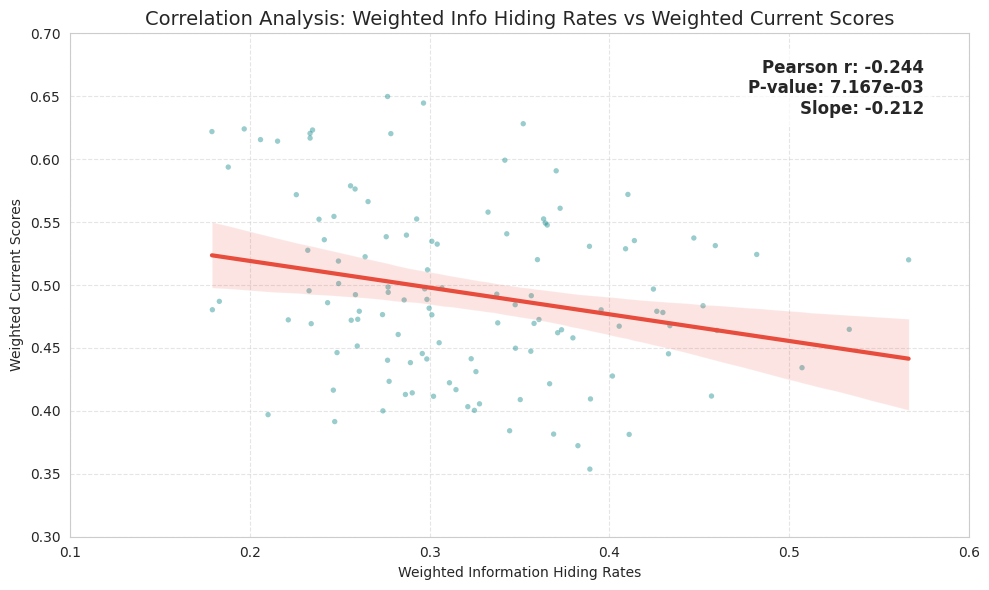

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats  # 用于计算统计指标

# 1. 计算统计指标 (相关系数 r 和 p-value)
slope, intercept, r_value, p_value, std_err = stats.linregress(weighted_info_hiding_rate, weighted_current_scores)

plt.figure(figsize=(10, 6))

# 2. 绘制带拟合线的散点图
sns.regplot(x=weighted_info_hiding_rate, y=weighted_current_scores,
            scatter_kws={'s': 15, 'alpha': 0.4, 'edgecolors': 'none'},
            line_kws={'color': '#e74c3c', 'lw': 3}, # 使用更醒目的红色
            color='teal')

# 3. 在图上显示具体指标
# 我们把文字放在右上角空白处 (x=0.65, y=0.85 附近)
stats_text = (f'Pearson r: {r_value:.3f}\n'
              f'P-value: {p_value:.3e}\n'
              f'Slope: {slope:.3f}')

# 使用 bbox 给文字加一个半透明底色，防止被点遮挡
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes, # 使用相对坐标 (0-1)
         verticalalignment='top',
         horizontalalignment='right',
         fontsize=12,
         fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

# 4. 图表修饰
plt.xlim(0.1, 0.6)
plt.ylim(0.3, 0.7)
plt.title('Correlation Analysis: Weighted Info Hiding Rates vs Weighted Current Scores', fontsize=14)
plt.xlabel('Weighted Information Hiding Rates')
plt.ylabel('Weighted Current Scores')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
len(all_current_scores)

2090

In [ ]:
all_rewritten_scores = [sum(score)/len(score) for conversation in LDS_rewritten_scores for score in conversation]
all_rewritten_scores.extend([sum(score)/len(score) for conversation in ESS_rewritten_scores for score in conversation])
all_rewritten_scores.extend([sum(score)/len(score) for conversation in RNS_rewritten_scores for score in conversation])

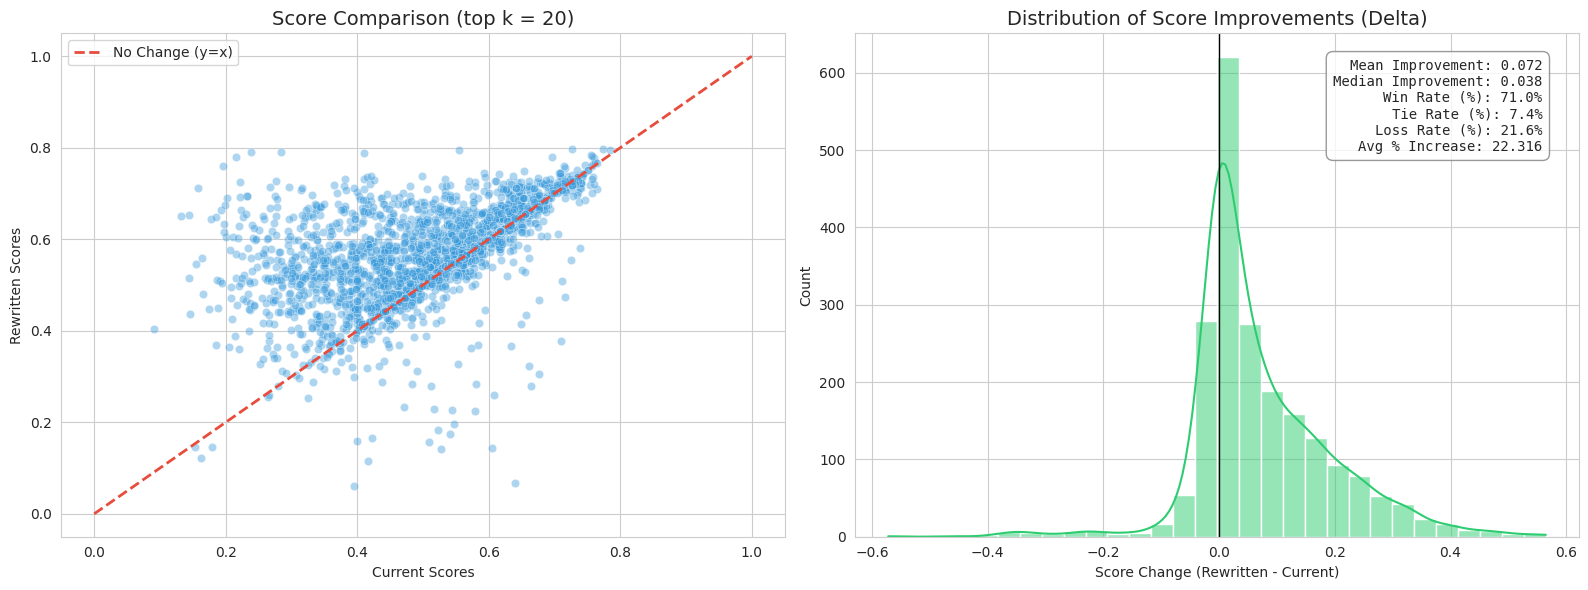

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 假设你的数据是 numpy 数组
current = np.array(all_current_scores)
rewritten = np.array(all_rewritten_scores)
diff = rewritten - current
# 计算提升百分比 (避免除以0)
pct_change = (diff / np.where(current == 0, np.nan, current)) * 100

# --- 统计数值计算 ---
# 这里的 diff == 0 即为平局
stats = {
    "Mean Improvement": np.mean(diff),
    "Median Improvement": np.median(diff),
    "Win Rate (%)": (diff > 0).mean() * 100,
    "Tie Rate (%)": (diff == 0).mean() * 100,  # <-- 新增：计算平局率
    "Loss Rate (%)": (diff < 0).mean() * 100, # <-- 建议：加上胜负平更完整
    "Avg % Increase": np.nanmean(pct_change)
}

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# [图1部分保持不变...]
sns.scatterplot(x=current, y=rewritten, alpha=0.4, ax=axes[0], color='#3498db')
axes[0].plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', lw=2, label='No Change (y=x)')
axes[0].set_title('Score Comparison (top k = 20)', fontsize=14)
axes[0].set_xlabel('Current Scores')
axes[0].set_ylabel('Rewritten Scores')
axes[0].legend()

# [图2部分]
sns.histplot(diff, kde=True, ax=axes[1], color='#2ecc71', bins=30)
axes[1].axvline(0, color='black', linestyle='-', lw=1)
axes[1].set_title('Distribution of Score Improvements (Delta)', fontsize=14)
axes[1].set_xlabel('Score Change (Rewritten - Current)')

# 修改统计信息文字框的逻辑，以匹配新增的 "Rate" 字段
stats_text = "\n".join([
    f"{k}: {v:.3f}" if "Rate" not in k else f"{k}: {v:.1f}%"
    for k, v in stats.items()
])

bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8)
axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes, verticalalignment='top',
             horizontalalignment='right', fontsize=10, bbox=bbox_props, family='monospace')

plt.tight_layout()
plt.show()

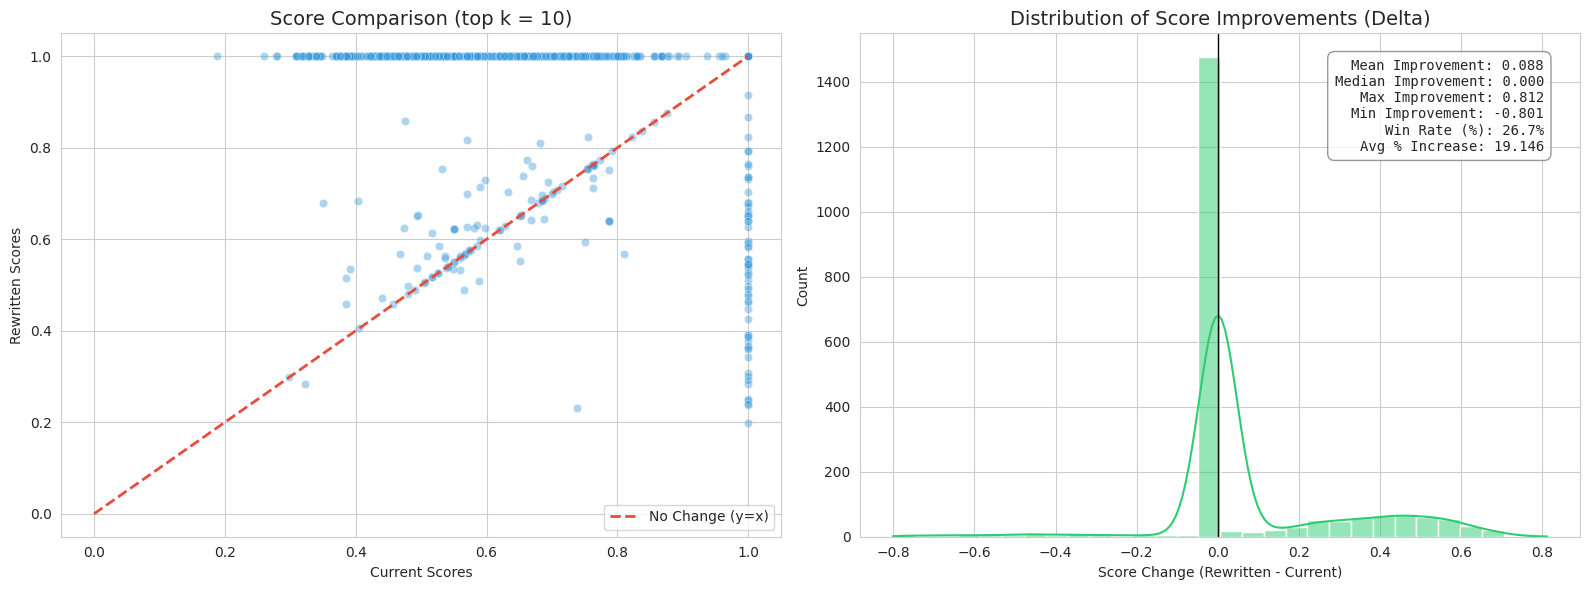

In [ ]:
# topk=20

all_top_current_scores = [max(score) for conversation in LDS_current_scores for score in conversation]
all_top_current_scores.extend([max(score) for conversation in ESS_current_scores for score in conversation])
all_top_current_scores.extend([max(score) for conversation in RNS_current_scores for score in conversation])

all_top_rewritten_scores = [max(score) for conversation in LDS_rewritten_scores for score in conversation]
all_top_rewritten_scores.extend([max(score) for conversation in ESS_rewritten_scores for score in conversation])
all_top_rewritten_scores.extend([max(score) for conversation in RNS_rewritten_scores for score in conversation])

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 假设你的数据是 numpy 数组
current = np.array(all_top_current_scores)
rewritten = np.array(all_top_rewritten_scores)
diff = rewritten - current
# 计算提升百分比 (避免除以0)
pct_change = (diff / np.where(current == 0, np.nan, current)) * 100

# --- 统计数值计算 ---
stats = {
    "Mean Improvement": np.mean(diff),
    "Median Improvement": np.median(diff),
    "Max Improvement": np.max(diff),
    "Min Improvement": np.min(diff),
    "Win Rate (%)": (diff > 0).mean() * 100,
    "Avg % Increase": np.nanmean(pct_change)
}

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# 图1: 散点对比图 (带 y=x 线)
sns.scatterplot(x=current, y=rewritten, alpha=0.4, ax=axes[0], color='#3498db')
axes[0].plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', lw=2, label='No Change (y=x)')
axes[0].set_title('Score Comparison (top k = 10)', fontsize=14)
axes[0].set_xlabel('Current Scores')
axes[0].set_ylabel('Rewritten Scores')
axes[0].legend()

# 图2: 提升值的分布 (带统计信息)
sns.histplot(diff, kde=True, ax=axes[1], color='#2ecc71', bins=30)
axes[1].axvline(0, color='black', linestyle='-', lw=1)
axes[1].set_title('Distribution of Score Improvements (Delta)', fontsize=14)
axes[1].set_xlabel('Score Change (Rewritten - Current)')

# 在图中添加统计信息文字框
stats_text = "\n".join([f"{k}: {v:.3f}" if "Rate" not in k else f"{k}: {v:.1f}%" for k, v in stats.items()])
bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8)
axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes, verticalalignment='top',
             horizontalalignment='right', fontsize=10, bbox=bbox_props, family='monospace')

plt.tight_layout()
plt.show()

In [ ]:
# topk=10

ten_top_current_scores = [max(score[:10]) for conversation in LDS_current_scores for score in conversation]
ten_top_current_scores.extend([max(score[:10]) for conversation in ESS_current_scores for score in conversation])
ten_top_current_scores.extend([max(score[:10]) for conversation in RNS_current_scores for score in conversation])

ten_top_rewritten_scores = [max(score[:10]) for conversation in LDS_rewritten_scores for score in conversation]
ten_top_rewritten_scores.extend([max(score[:10]) for conversation in ESS_rewritten_scores for score in conversation])
ten_top_rewritten_scores.extend([max(score[:10]) for conversation in RNS_rewritten_scores for score in conversation])

# topk=5

five_top_current_scores = [max(score[:5]) for conversation in LDS_current_scores for score in conversation]
five_top_current_scores.extend([max(score[:5]) for conversation in ESS_current_scores for score in conversation])
five_top_current_scores.extend([max(score[:5]) for conversation in RNS_current_scores for score in conversation])

five_top_rewritten_scores = [max(score[:5]) for conversation in LDS_rewritten_scores for score in conversation]
five_top_rewritten_scores.extend([max(score[:5]) for conversation in ESS_rewritten_scores for score in conversation])
five_top_rewritten_scores.extend([max(score[:5]) for conversation in RNS_rewritten_scores for score in conversation])

# topk=3

three_top_current_scores = [max(score[:3]) for conversation in LDS_current_scores for score in conversation]
three_top_current_scores.extend([max(score[:3]) for conversation in ESS_current_scores for score in conversation])
three_top_current_scores.extend([max(score[:3]) for conversation in RNS_current_scores for score in conversation])

three_top_rewritten_scores = [max(score[:3]) for conversation in LDS_rewritten_scores for score in conversation]
three_top_rewritten_scores.extend([max(score[:3]) for conversation in ESS_rewritten_scores for score in conversation])
three_top_rewritten_scores.extend([max(score[:3]) for conversation in RNS_rewritten_scores for score in conversation])

# topk=1

one_top_current_scores = [max(score[:3]) for conversation in LDS_current_scores for score in conversation]
one_top_current_scores.extend([max(score[:3]) for conversation in ESS_current_scores for score in conversation])
one_top_current_scores.extend([max(score[:3]) for conversation in RNS_current_scores for score in conversation])

one_top_rewritten_scores = [max(score[:3]) for conversation in LDS_rewritten_scores for score in conversation]
one_top_rewritten_scores.extend([max(score[:3]) for conversation in ESS_rewritten_scores for score in conversation])
one_top_rewritten_scores.extend([max(score[:3]) for conversation in RNS_rewritten_scores for score in conversation])

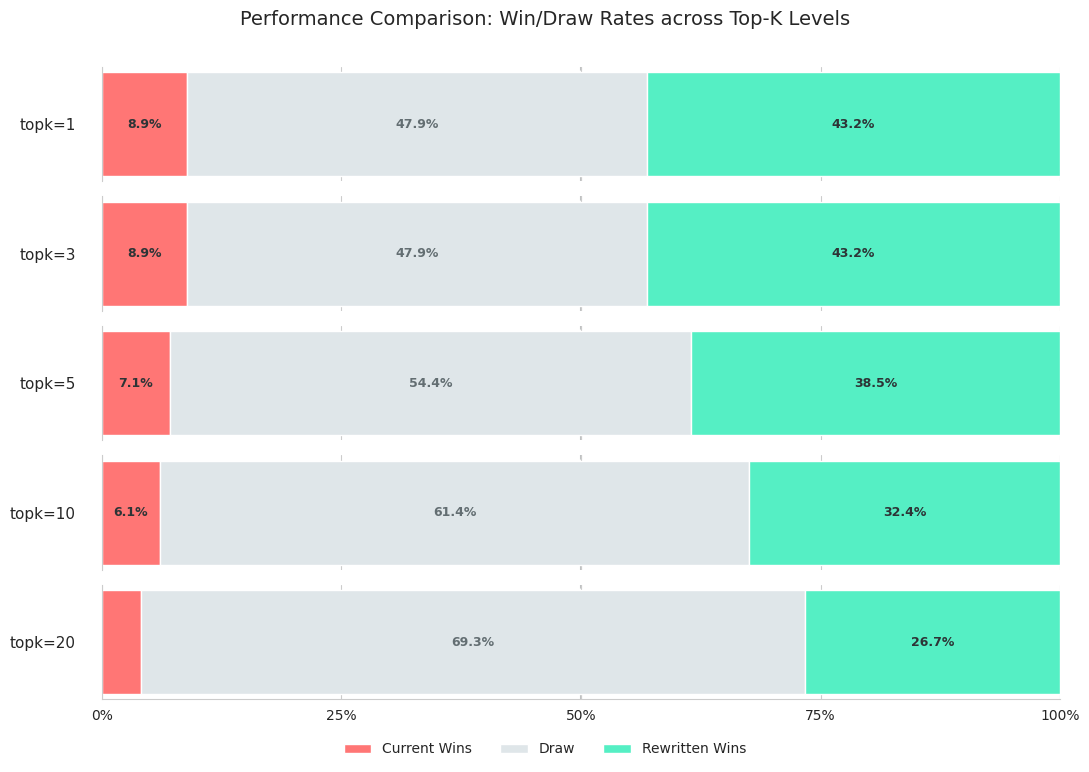

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据组
data_groups = [
    ("topk=1", one_top_current_scores, one_top_rewritten_scores),
    ("topk=3", three_top_current_scores, three_top_rewritten_scores),
    ("topk=5", five_top_current_scores, five_top_rewritten_scores),
    ("topk=10", ten_top_current_scores, ten_top_rewritten_scores),
    ("topk=20", all_top_current_scores, all_top_rewritten_scores)
]

fig, axes = plt.subplots(5, 1, figsize=(11, 8), sharex=True)
plt.subplots_adjust(hspace=0.5)

for i, (label, curr_list, rewr_list) in enumerate(data_groups):
    curr = np.array(curr_list)
    rewr = np.array(rewr_list)

    total = len(curr)
    r_wins = np.sum(rewr > curr)
    c_wins = np.sum(curr > rewr)
    draws = np.sum(rewr == curr)

    rw_rate = (r_wins / total) * 100
    cw_rate = (c_wins / total) * 100
    d_rate = (draws / total) * 100

    ax = axes[i]

    # 绘图：Current Wins (红) | Draw (灰) | Rewritten Wins (绿)
    ax.barh([label], [cw_rate], color='#ff7675', label='Current Wins' if i==0 else "")
    ax.barh([label], [d_rate], left=[cw_rate], color='#dfe6e9', label='Draw' if i==0 else "")
    ax.barh([label], [rw_rate], left=[cw_rate + d_rate], color='#55efc4', label='Rewritten Wins' if i==0 else "")

    # --- 数值标注逻辑：全部放在对应的区间中心 ---
    # 设定显示阈值，比例太小时不显示文字避免重叠
    threshold = 5.0

    # 1. 标注 Current Win Rate
    if cw_rate > threshold:
        ax.text(cw_rate/2, 0, f'{cw_rate:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='#2d3436')

    # 2. 标注 Draw Rate (放在灰色区间中心)
    if d_rate > threshold:
        ax.text(cw_rate + d_rate/2, 0, f'{d_rate:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='#636e72')

    # 3. 标注 Rewritten Win Rate
    if rw_rate > threshold:
        ax.text(cw_rate + d_rate + rw_rate/2, 0, f'{rw_rate:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='#2d3436')

    # 基础样式设置
    ax.set_xlim(0, 100)
    ax.axvline(50, color='#2d3436', linestyle='--', alpha=0.3, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='y', labelsize=11, pad=15)

# X轴设置
axes[-1].set_xticks([0, 25, 50, 75, 100])
axes[-1].set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
axes[-1].spines['bottom'].set_visible(True)

# 图例和标题
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.06), ncol=3, frameon=False)
plt.suptitle('Performance Comparison: Win/Draw Rates across Top-K Levels', fontsize=14, y=0.96)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()